In [ ]:
import numpy as np
import pickle
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from utils.cluster_utils import*
import pandas as pd

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage 
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import dendrogram



try:
    with open('weightedFrames.pkl', 'rb') as f:
        frameMatrix = pickle.load(f)
except:
    print("Error")


## Ablation study on feature groups 

In [2]:
#dividing feature groups

gpdMatrix = frameMatrix[:, :50]
tableMatrix = frameMatrix[:, 50:55] 
interpersonMatrix = frameMatrix[:, 55:] 

In [3]:
##grouping per operation
OP_RANGES = [
    (0, 6),      # day3 op6: 7
    (7, 29),     # day3 op3: 23
    (30, 37),    # day3 op9: 8
    (38, 70),    # day3 op5: 33
    (71, 80),    # day3 op8: 10
    (81, 101),   # day3 op4: 21
    (102, 122),  # day3 op7: 21
    (123, 137),  # day3 op11: 15
    (138, 154),  # day3 op2: 17
    (155, 167),  # day3 op10: 13
    (168, 174),  # day3 op1: 7
    (175, 279),  # day2 op1: 105
    (280, 302),  # day2 op9: 23
    (303, 399),  # day2 op2: 97
    (400, 411),  # day2 op6: 12
    (412, 418),  # day2 op7: 7
    (419, 429),  # day2 op5: 11
    (430, 440),  # day2 op8: 11
    (441, 444),  # day2 op11: 4
    (445, 452),  # day2 op4: 8
    # (453, 454),  # day2 op3: 2
    # (455, 456),  # day2 op10: 2 <-- excluded due to length
    (457, 526),  # day4 op1: 70
    (527, 567),  # day4 op2: 41
    (568, 572),  # day4 op3: 5
    (573, 625),  # day1 op1: 53
]


#group per operation for each feature type
gpdVectors = []
tableVectors = []
interpersonVectors = []

for r in OP_RANGES:
    op = gpdMatrix[r[0]:r[1]+1,]
    gpdVectors.append(op)

for r in OP_RANGES:
    op = tableMatrix[r[0]:r[1]+1,]
    tableVectors.append(op)


for r in OP_RANGES:
    op = interpersonMatrix[r[0]:r[1]+1,]
    interpersonVectors.append(op)

opLabels = [f"op{i}" for i in range(1, 25)]



In [4]:
gpdDists = n_dtw(gpdVectors)
gpdEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(gpdDists)

tableDists = n_dtw(tableVectors)
tableEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(tableDists)

interpersonDists = n_dtw(interpersonVectors)
interpersonEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(interpersonDists)


In [5]:
g_condensedDist = squareform(gpdDists)
g_linkage = linkage(g_condensedDist, method='complete') 

t_condensedDist = squareform(tableDists)
t_linkage = linkage(t_condensedDist, method='complete') 

i_condensedDist = squareform(interpersonDists)
i_linkage = linkage(i_condensedDist, method='complete') 




In [ ]:
##plotting all 3 dendrograms side by side
fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

dendrogram(g_linkage,  ax = ax1, labels = opLabels)
dendrogram(t_linkage, ax = ax2, labels = opLabels)
dendrogram(i_linkage, ax = ax3, labels = opLabels)

ax1.set_title("Gpd features")
ax2.set_title("Table features")
ax3.set_title("Interperson features")

plt.show()

Text(0.5, 1.0, 'Interperson features')

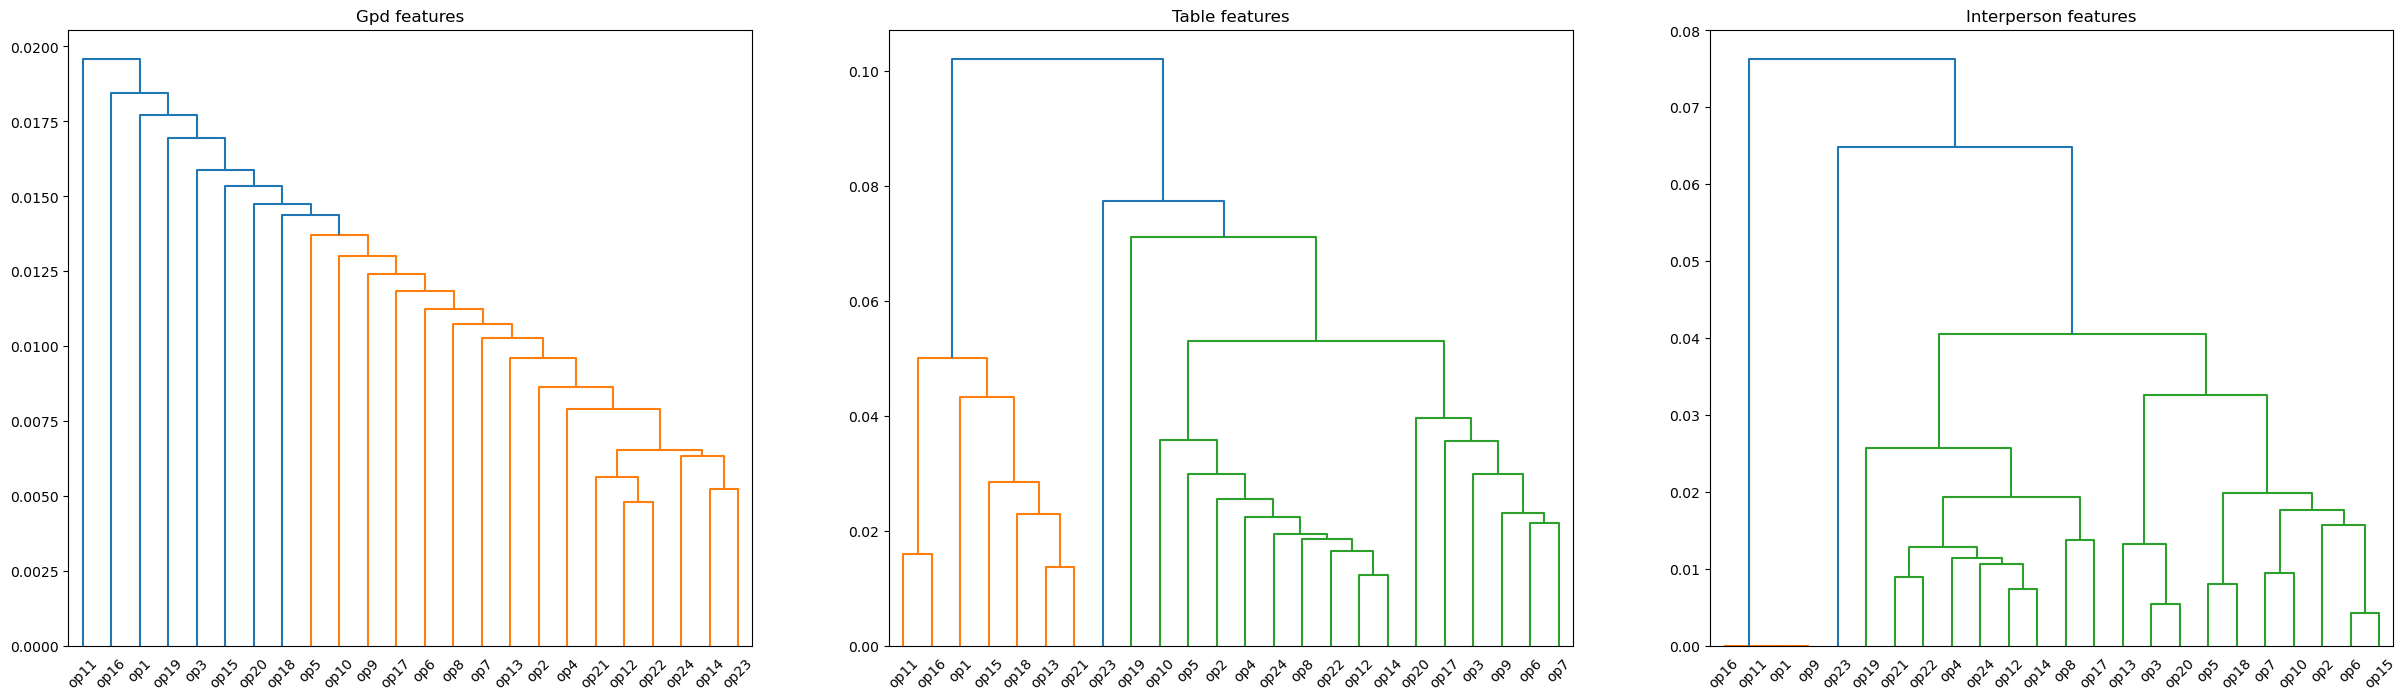

In [6]:
g_condensedDist = squareform(gpdDists)
g_linkage = linkage(g_condensedDist, method='ward') 

t_condensedDist = squareform(tableDists)
t_linkage = linkage(t_condensedDist, method='ward') 

i_condensedDist = squareform(interpersonDists)
i_linkage = linkage(i_condensedDist, method='ward') 

##plotting all 3 dendrograms side by side
fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

dendrogram(g_linkage,  ax = ax1, labels = opLabels)
dendrogram(t_linkage, ax = ax2, labels = opLabels)
dendrogram(i_linkage, ax = ax3, labels = opLabels)

ax1.set_title("Gpd features")
ax2.set_title("Table features")
ax3.set_title("Interperson features")


In [ ]:
gpd_hierachical_labels = fcluster(g_linkage, t=3, criterion='maxclust') 
table_hierachical_labels = fcluster(t_linkage, t=3, criterion='maxclust') 
interp_hierachical_labels = fcluster(i_linkage, t=3, criterion='maxclust') 

fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

ax1.scatter(gpdEmbedding[:, 0], gpdEmbedding[:,1], c=gpd_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdEmbedding[i, 0], gpdEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(tableEmbedding[:, 0], tableEmbedding[:,1], c=table_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (tableEmbedding[i, 0], tableEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=interp_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"Hierachical clustering - gpd features")
ax2.set_title(f"Hierachical clustering - table features")
ax3.set_title(f"Hierachical clustering - interperson features")


plt.show()

In [11]:
from sklearn.metrics.cluster import adjusted_rand_score, fowlkes_mallows_score

In [ ]:
print(f'ARI gpd v table: {adjusted_rand_score(gpd_hierachical_labels, table_hierachical_labels)}')
print(f'ARI gpd v interperson: {adjusted_rand_score(gpd_hierachical_labels, interp_hierachical_labels)}')
print(f'ARI table vs interperson: {adjusted_rand_score(table_hierachical_labels, interp_hierachical_labels)}')

In [ ]:
_, gpd_kmeans = kMeans_nDTW(gpdVectors , k=3)


In [ ]:
_, table_kmeans = kMeans_nDTW(tableVectors , k=3)


In [ ]:
_, interperson_kmeans = kMeans_nDTW(interpersonVectors , k=3)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

ax1.scatter(gpdEmbedding[:, 0], gpdEmbedding[:,1], c=gpd_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdEmbedding[i, 0], gpdEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(tableEmbedding[:, 0], tableEmbedding[:,1], c=table_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (tableEmbedding[i, 0], tableEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=interperson_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"Kmeans (k=3) - gpd features")
ax2.set_title(f"Kmeans (k=3)- table features")
ax3.set_title(f"Kmeans (k=3) - interperson features")

In [ ]:
print(f'ARI gpd v table: {adjusted_rand_score(gpd_kmeans, table_kmeans)}')
print(f'ARI gpd v interperson: {adjusted_rand_score(gpd_kmeans, interperson_kmeans)}')
print(f'ARI table vs interperson: {adjusted_rand_score(table_kmeans, interperson_kmeans)}')

In [7]:
_, gpd_kmeans_k2 = kMeans_nDTW(gpdVectors)
_, table_kmeans_k2 = kMeans_nDTW(tableVectors)
_, interperson_kmeans_k2 = kMeans_nDTW(interpersonVectors)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

ax1.scatter(gpdEmbedding[:, 0], gpdEmbedding[:,1], c=gpd_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdEmbedding[i, 0], gpdEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(tableEmbedding[:, 0], tableEmbedding[:,1], c=table_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (tableEmbedding[i, 0], tableEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=interperson_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"Kmeans (k=2) - gpd features")
ax2.set_title(f"Kmeans (k=2)- table features")
ax3.set_title(f"Kmeans (k=2) - interperson features")

In [ ]:
print(f'ARI gpd v table: {adjusted_rand_score(gpd_kmeans_k2, table_kmeans_k2)}')
print(f'ARI gpd v interperson: {adjusted_rand_score(gpd_kmeans_k2, interperson_kmeans_k2)}')
print(f'ARI table vs interperson: {adjusted_rand_score(table_kmeans_k2, interperson_kmeans_k2)}')

### Algorithm agreement

In [ ]:
print(f'ARI gpd : {adjusted_rand_score(gpd_kmeans, gpd_hierachical_labels)}')
print(f'ARI interperson: {adjusted_rand_score(interperson_kmeans, interp_hierachical_labels)}')
print(f'ARI table: {adjusted_rand_score(table_kmeans, table_hierachical_labels)}')

### Comparing results against annotations

In [9]:
orientation_labels = [1, 1, 1, 2, 1, 2, 1, 3, 2, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1] # 1 if down, 2 if up, 3 if side
machinery_labels = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1] # 1 if c machine is present, 0 otherwise

labelsk2 = [gpd_kmeans_k2, table_kmeans_k2, interperson_kmeans_k2]
# labelsk3 = [gpd_kmeans, gpd_hierachical_labels, interperson_kmeans, interp_hierachical_labels, table_kmeans, table_hierachical_labels]

In [ ]:
for i, label in enumerate(labelsk3):    
    print(f'ARI: {adjusted_rand_score(orientation_labels, labelsk3[i])}')


In [12]:
for i, label in enumerate(labelsk2): 
    print(f'ARI: {adjusted_rand_score(machinery_labels, labelsk2[i])}')


ARI: -0.057096247960848286
ARI: 0.026136957658128592
ARI: 0.3943051516980304


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20,16))
ax1, ax2, ax3, ax4 = axes.flatten()

ax1.scatter(gpdEmbedding[:, 0], gpdEmbedding[:,1], c=gpd_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdEmbedding[i, 0], gpdEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(gpdEmbedding[:, 0], gpdEmbedding[:,1], c=machinery_labels, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (gpdEmbedding[i, 0], gpdEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=interperson_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax4.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=machinery_labels, s=100)

for i, op in enumerate(opLabels):
    ax4.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"Kmeans (k=2) - gpd features")
ax2.set_title(f"machinery labels - gpd embedding")


ax3.set_title(f"Kmeans (k=2) - interperson features")
ax4.set_title(f"machinery - interperson embedding")


#### operations over 10 frames

In [13]:
gpd_over10 = []
table_over10 = []
interperson_over10 = []

for i, operation in enumerate(gpdVectors):
    if len(operation)>=10:
        gpd_over10.append(gpdVectors[i])
        table_over10.append(tableVectors[i])
        interperson_over10.append(interpersonVectors[i])

In [14]:
_, gpd_over10_kmeans = kMeans_nDTW(gpd_over10)
_, table_over10_kmeans= kMeans_nDTW(table_over10)
_, interperson_over10_kmeans = kMeans_nDTW(interperson_over10)

In [15]:
labels_over10 = [gpd_over10_kmeans, table_over10_kmeans, interperson_over10_kmeans]

machinery_labels_over10 =   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1] # 1 if c machine is present, 0 otherwise


In [16]:
for i, label in enumerate(labels_over10): 
    print(f'ARI: {adjusted_rand_score(machinery_labels_over10, labels_over10[i])}')

ARI: -0.05154639175257732
ARI: 0.03608247422680412
ARI: 0.5557491289198606


In [ ]:
interpersonDists_over10 = n_dtw(interperson_over10)
interpersonEmbedding_over10 = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(interpersonDists_over10)

over10Labels = [f'op{i}' for i in range(1,len(interperson_over10)+1)]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(interpersonEmbedding_over10[:, 0], interpersonEmbedding_over10[:,1], c=interperson_over10_kmeans, s=100)

for i, op in enumerate(over10Labels):
    ax1.annotate(op, (interpersonEmbedding_over10[i, 0], interpersonEmbedding_over10[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(interpersonEmbedding_over10[:, 0], interpersonEmbedding_over10[:,1], c=machinery_labels_over10, s=100)

for i, op in enumerate(over10Labels):
    ax2.annotate(op, (interpersonEmbedding_over10[i, 0], interpersonEmbedding_over10[i ,1]), fontsize=7, ha='right', rotation=45)

    
ax1.set_title(f"Kmeans (k=2) interperson group- operations over 10 frames")
ax2.set_title(f"Machinery- operations over 10 frames")

plt.show()

In [ ]:
## checking if results are consistent for hiearchical clustering
i_over10_condensedDist = squareform(interpersonDists_over10)
i_over10_linkage = linkage(i_over10_condensedDist, method='complete') 

interp_hierachical_labels_over10 = fcluster(i_over10_linkage, t=2, criterion='maxclust') 
print(f'ARI complete linkage: {adjusted_rand_score(machinery_labels_over10 , interp_hierachical_labels_over10)}')


In [ ]:
## checking if results are consistent for hiearchical clustering
i_over10_condensedDist = squareform(interpersonDists_over10)
i_over10_linkage = linkage(i_over10_condensedDist, method='ward') 

interp_hierachical_labels_over10 = fcluster(i_over10_linkage, t=2, criterion='maxclust') 
print(f'ARI ward linkage: {adjusted_rand_score(machinery_labels_over10 , interp_hierachical_labels_over10)}')

## checking if results are consistent for hiearchical clustering
i_over10_condensedDist = squareform(interpersonDists_over10)
i_over10_linkage = linkage(i_over10_condensedDist, method='single') 

interp_hierachical_labels_over10 = fcluster(i_over10_linkage, t=2, criterion='maxclust') 
print(f'ARI single linkage: {adjusted_rand_score(machinery_labels_over10 , interp_hierachical_labels_over10)}')

## checking if results are consistent for hiearchical clustering
i_over10_condensedDist = squareform(interpersonDists_over10)
i_over10_linkage = linkage(i_over10_condensedDist, method='average') 

interp_hierachical_labels_over10 = fcluster(i_over10_linkage, t=2, criterion='maxclust') 
print(f'ARI average linkage: {adjusted_rand_score(machinery_labels_over10 , interp_hierachical_labels_over10)}')


In [ ]:
print(f'ARI complete linkage: {adjusted_rand_score(interperson_over10_kmeans , interp_hierachical_labels_over10)}')


## Feature group subsets

In [17]:
gpd_table_matrix = np.hstack([gpdMatrix, tableMatrix])
gpd_interperson_matrix = np.hstack([gpdMatrix, interpersonMatrix])
table_interperson_matrix = np.hstack([interpersonMatrix, tableMatrix])

In [18]:
gpdTable = []
gpdInterperson = []
tableInterperson = []

for r in OP_RANGES:
    op = gpd_table_matrix[r[0]:r[1]+1,]
    gpdTable.append(op)

for r in OP_RANGES:
    op = gpd_interperson_matrix[r[0]:r[1]+1,]
    gpdInterperson.append(op)


for r in OP_RANGES:
    op = table_interperson_matrix[r[0]:r[1]+1,]
    tableInterperson.append(op)

In [19]:
gpdTableDists = n_dtw(gpdTable)
gpdTableEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(gpdTableDists)

gpdInterpersonDists = n_dtw(gpdInterperson)
gpdInterpersonEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(gpdInterpersonDists)

tableInterpersonDists = n_dtw(tableInterperson)
interpersonEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(tableInterpersonDists)


gt_condensedDist = squareform(gpdTableDists)
gt_linkage = linkage(gt_condensedDist, method='complete') 

gi_condensedDist = squareform(gpdInterpersonDists)
gi_linkage = linkage(gi_condensedDist, method='complete') 

ti_condensedDist = squareform(tableInterpersonDists)
ti_linkage = linkage(ti_condensedDist, method='complete') 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

dendrogram(gt_linkage,  ax = ax1, labels = opLabels)
dendrogram(gi_linkage, ax = ax2, labels = opLabels)
dendrogram(ti_linkage, ax = ax3, labels = opLabels)

ax1.set_title("Gpd + table features")
ax2.set_title("Gpd + interperson features")
ax3.set_title("Table + interperson features")

plt.show()

In [ ]:
##grouping subsets (k=3)
gt_hierachical_labels = fcluster(gt_linkage, t=4, criterion='maxclust')  #19 and 23 were being given their own clusters at k=3
gi_hierachical_labels = fcluster(gi_linkage, t=3, criterion='maxclust') 
ti_hierachical_labels = fcluster(ti_linkage, t=3, criterion='maxclust') 


fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

ax1.scatter(gpdTableEmbedding[:, 0], gpdTableEmbedding[:,1], c=gt_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdTableEmbedding[i, 0], gpdTableEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(gpdInterpersonEmbedding[:, 0], gpdInterpersonEmbedding[:,1], c=gi_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (gpdInterpersonEmbedding[i, 0], gpdInterpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=ti_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"HC (k=4) - gpd + table features")
ax2.set_title(f"HC (k=3)- gpd + interperson features")
ax3.set_title(f"HC (k=3) - table + interperson features")

In [ ]:
##aggreement 
print(f"{adjusted_rand_score(gt_hierachical_labels, gi_hierachical_labels)}")
print(f"{adjusted_rand_score(ti_hierachical_labels, gt_hierachical_labels)}")
print(f"{adjusted_rand_score(ti_hierachical_labels, gi_hierachical_labels)}")

Text(0.5, 1.0, 'Table + interperson features')

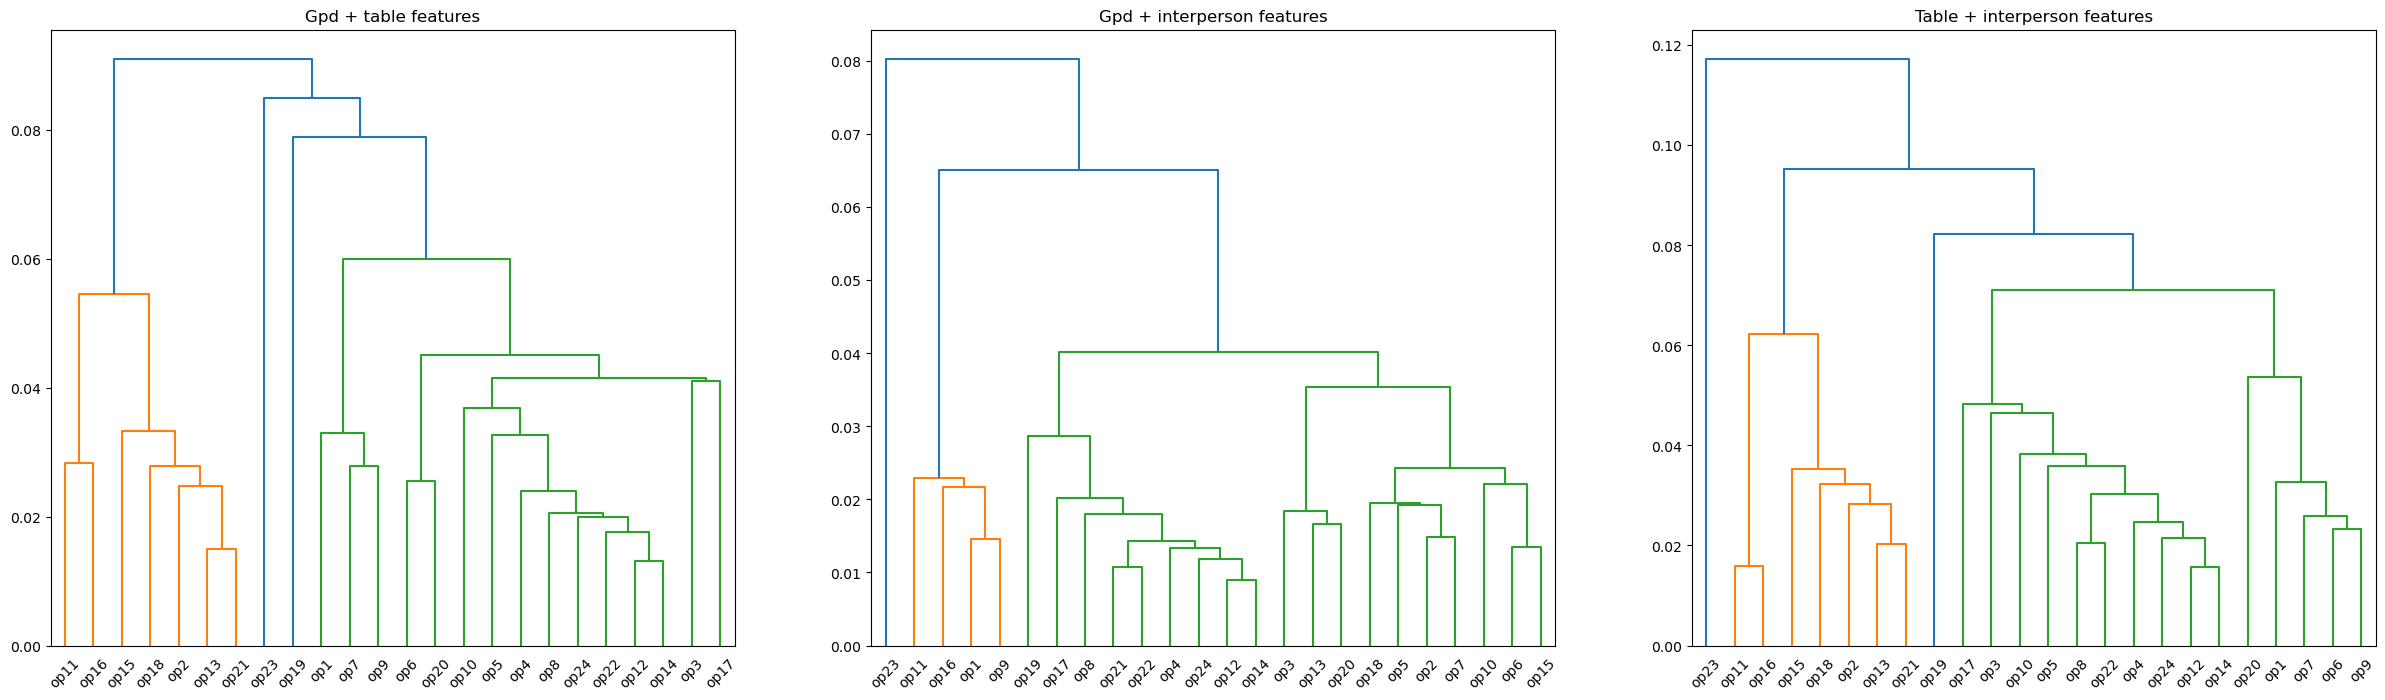

In [20]:
gt_linkage_ward = linkage(gt_condensedDist, method='ward') 
gi_linkage_ward = linkage(gi_condensedDist, method='ward') 
ti_linkage_ward = linkage(ti_condensedDist, method='ward') 

gt_hierachical_labels_w = fcluster(gt_linkage, t=2, criterion='maxclust')  #19 and 23 were being given their own clusters at k=3
gi_hierachical_labels_w = fcluster(gi_linkage, t=2, criterion='maxclust') 
ti_hierachical_labels_w = fcluster(ti_linkage, t=2, criterion='maxclust') 

fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

dendrogram(gt_linkage_ward,  ax = ax1, labels = opLabels)
dendrogram(gi_linkage_ward, ax = ax2, labels = opLabels)
dendrogram(ti_linkage_ward, ax = ax3, labels = opLabels)

ax1.set_title("Gpd + table features")
ax2.set_title("Gpd + interperson features")
ax3.set_title("Table + interperson features")

In [ ]:
#kmeans k = 3
_, gpdTable_kmeans = kMeans_nDTW(gpdTable, k=3)
_, gpdInterperson_kmeans= kMeans_nDTW(gpdInterperson, k=3)
_, tableInterperson_kmeans = kMeans_nDTW(tableInterperson, k=3)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

ax1.scatter(gpdTableEmbedding[:, 0], gpdTableEmbedding[:,1], c=gpdTable_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdTableEmbedding[i, 0], gpdTableEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(gpdInterpersonEmbedding[:, 0], gpdInterpersonEmbedding[:,1], c=gpdInterperson_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (gpdInterpersonEmbedding[i, 0], gpdInterpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=tableInterperson_kmeans , s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"Kmeans (k=3) - gpd + table features")
ax2.set_title(f"Kmeans (k=3)- gpd + interperson features")
ax3.set_title(f"Kmeanse (k=3) - table + interperson features")

Text(0.5, 1.0, 'Kmeans (k=2) - table + interperson features')

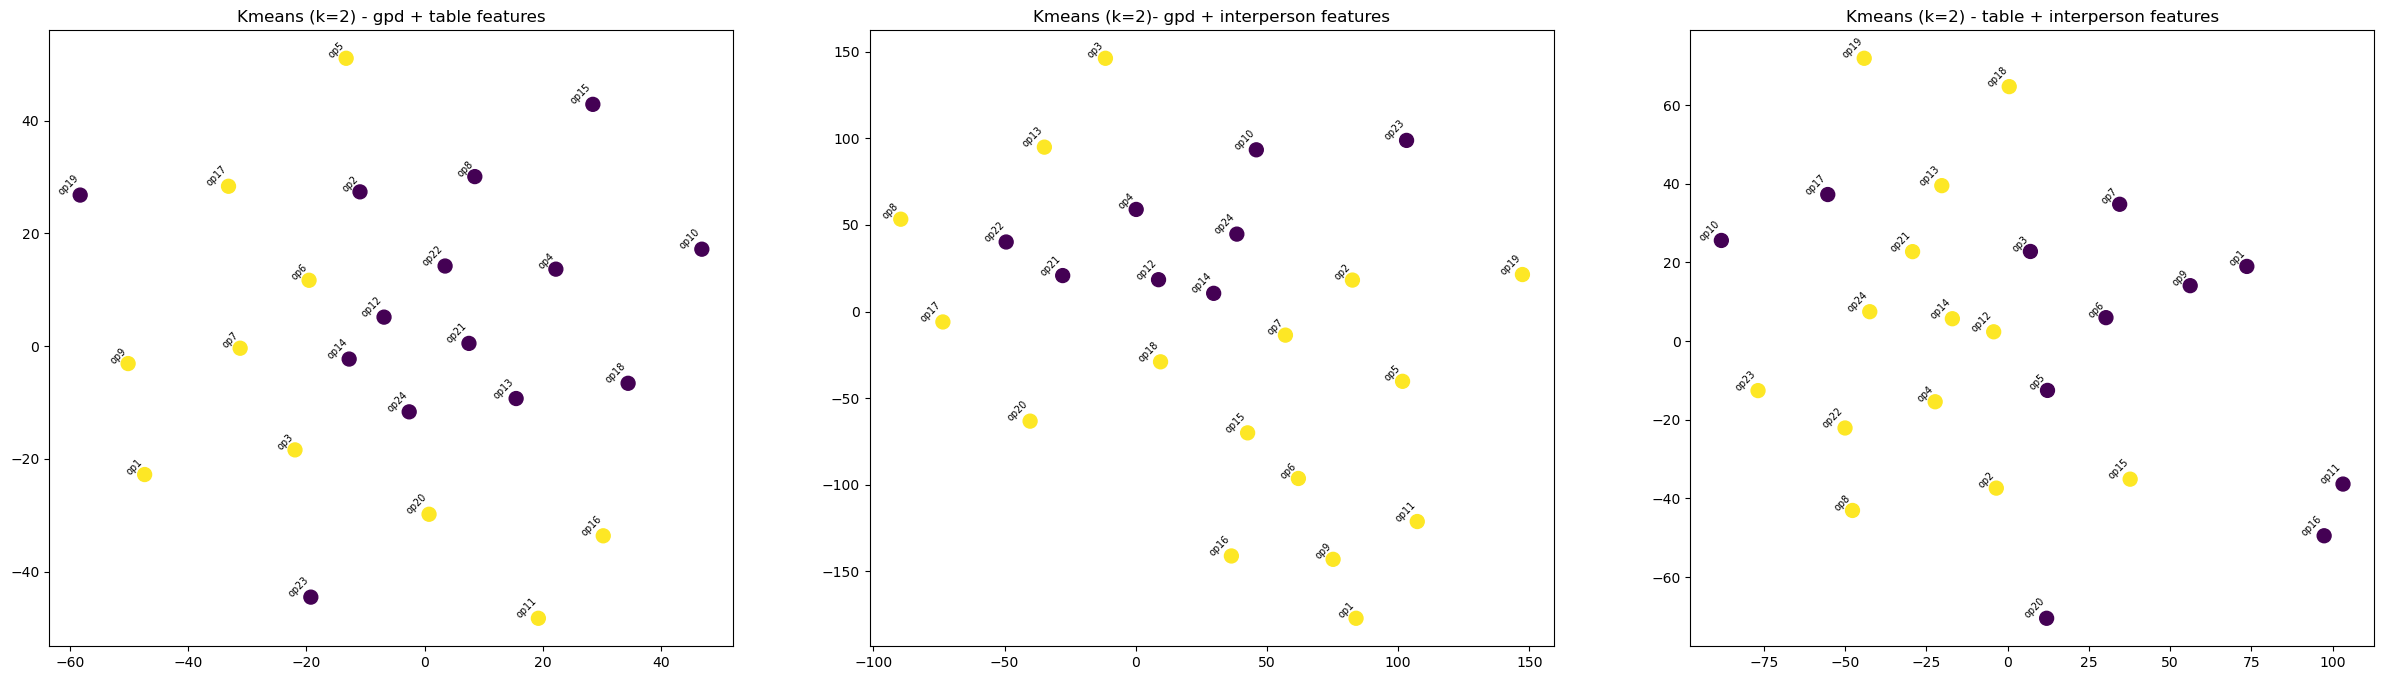

In [21]:
# kmeans k = 2
_, gpdTable_kmeans_k2 = kMeans_nDTW(gpdTable)
_, gpdInterperson_kmeans_k2= kMeans_nDTW(gpdInterperson)
_, tableInterperson_kmeans_k2 = kMeans_nDTW(tableInterperson)

fig, axes = plt.subplots(1, 3, figsize=(30, 8))
ax1, ax2, ax3 = axes.flatten()

ax1.scatter(gpdTableEmbedding[:, 0], gpdTableEmbedding[:,1], c=gpdTable_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (gpdTableEmbedding[i, 0], gpdTableEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(gpdInterpersonEmbedding[:, 0], gpdInterpersonEmbedding[:,1], c=gpdInterperson_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (gpdInterpersonEmbedding[i, 0], gpdInterpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(interpersonEmbedding[:, 0], interpersonEmbedding[:,1], c=tableInterperson_kmeans_k2 , s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (interpersonEmbedding[i, 0], interpersonEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax1.set_title(f"Kmeans (k=2) - gpd + table features")
ax2.set_title(f"Kmeans (k=2)- gpd + interperson features")
ax3.set_title(f"Kmeans (k=2) - table + interperson features")



In [22]:
#comparing to manual annotations
subset_labels= [gpdTable_kmeans_k2, gpdInterperson_kmeans_k2, tableInterperson_kmeans_k2, gt_hierachical_labels_w, gi_hierachical_labels_w, ti_hierachical_labels_w]

for i, label in enumerate(subset_labels): 
    print(f'ARI: {adjusted_rand_score(machinery_labels, subset_labels[i])}')

ARI: 0.026136957658128592
ARI: 0.2956914150639304
ARI: 0.08281842255568825
ARI: 0.12611651779762698
ARI: -0.057096247960848286
ARI: -0.057096247960848286


### Checking if over 10 frame subset produces better results

In [ ]:
gpdInterperson_over10 = []

for op in gpdInterperson:
    if len(op)>=10:
        gpdInterperson_over10.append(op)

_, gpdInterperson_over10_kmeans = kMeans_nDTW(gpdInterperson_over10)

In [ ]:
print(f"ARI over 10: {adjusted_rand_score(gpdInterperson_over10_kmeans, machinery_labels_over10)}")

In [ ]:
## comparing with just interperson over10

print(f"ARI over 10: {adjusted_rand_score(gpdInterperson_over10_kmeans, interperson_over10_kmeans )}")

Perfect agreement between gpdInterperson and just interperson and same ARI which would imply gpd isnt necessary

## Feature group weight ablation

In [23]:
try:
    with open('frameMatrixScaled.pkl', 'rb') as f:
        unweightedFrameMatrix = pickle.load(f)
except:
    print("Error")

### No group weighing

In [24]:
unweighted_operations = []

for r in OP_RANGES:
    op = unweightedFrameMatrix[r[0]:r[1]+1,]
    unweighted_operations.append(op)

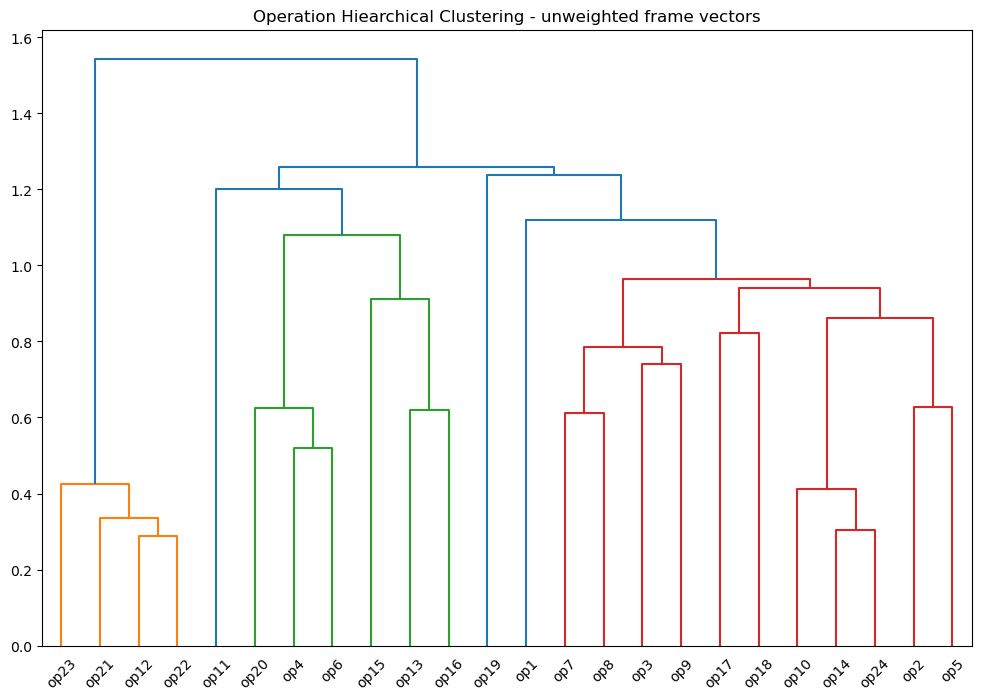

In [25]:
unweightedDists = n_dtw(unweighted_operations)
unweightedEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(unweightedDists)

u_condensedDist = squareform(unweightedDists)
unweighted_linkage = linkage(u_condensedDist, method='complete') 


plt.figure(figsize=(12, 8))
dendrogram(unweighted_linkage, labels = opLabels)
plt.title("Operation Hiearchical Clustering - unweighted frame vectors")
plt.show()

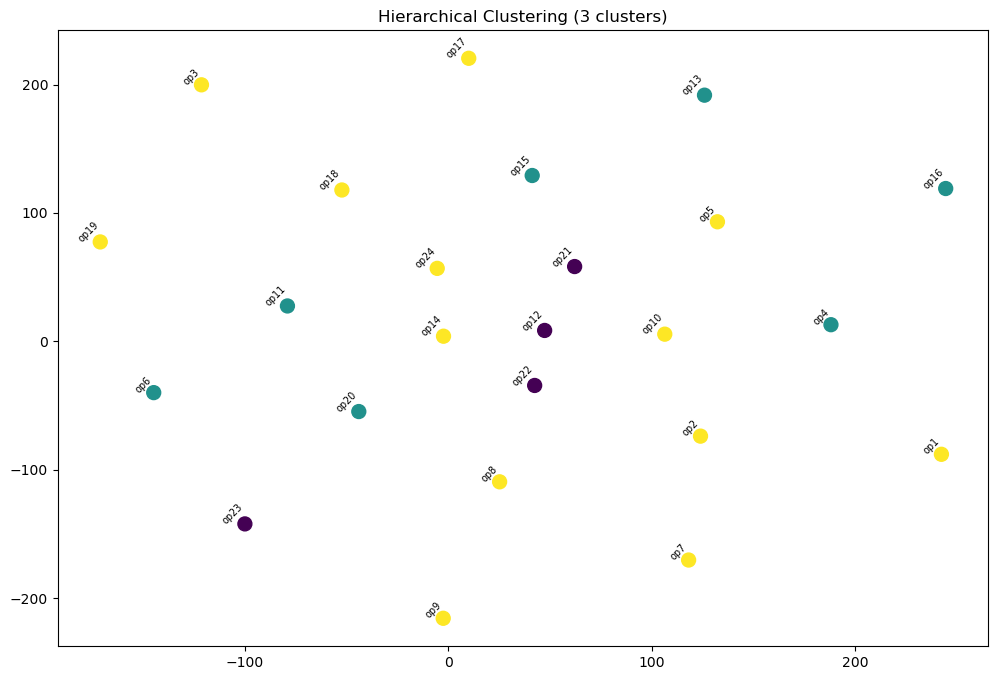

In [26]:
unweighted_hierachical_labels = fcluster(unweighted_linkage, t=3, criterion='maxclust') 

plt.figure(figsize=(12, 8))
plt.scatter(unweightedEmbedding[:, 0], unweightedEmbedding[:, 1], 
            c=unweighted_hierachical_labels, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (unweightedEmbedding[i, 0], unweightedEmbedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Hierarchical Clustering (3 clusters)')
plt.show()

In [27]:
_, unweighted_kmeans = kMeans_nDTW(unweighted_operations, k=3)
_, unweighted_kmeans_k2 = kMeans_nDTW(unweighted_operations)

NameError: name 'ax4' is not defined

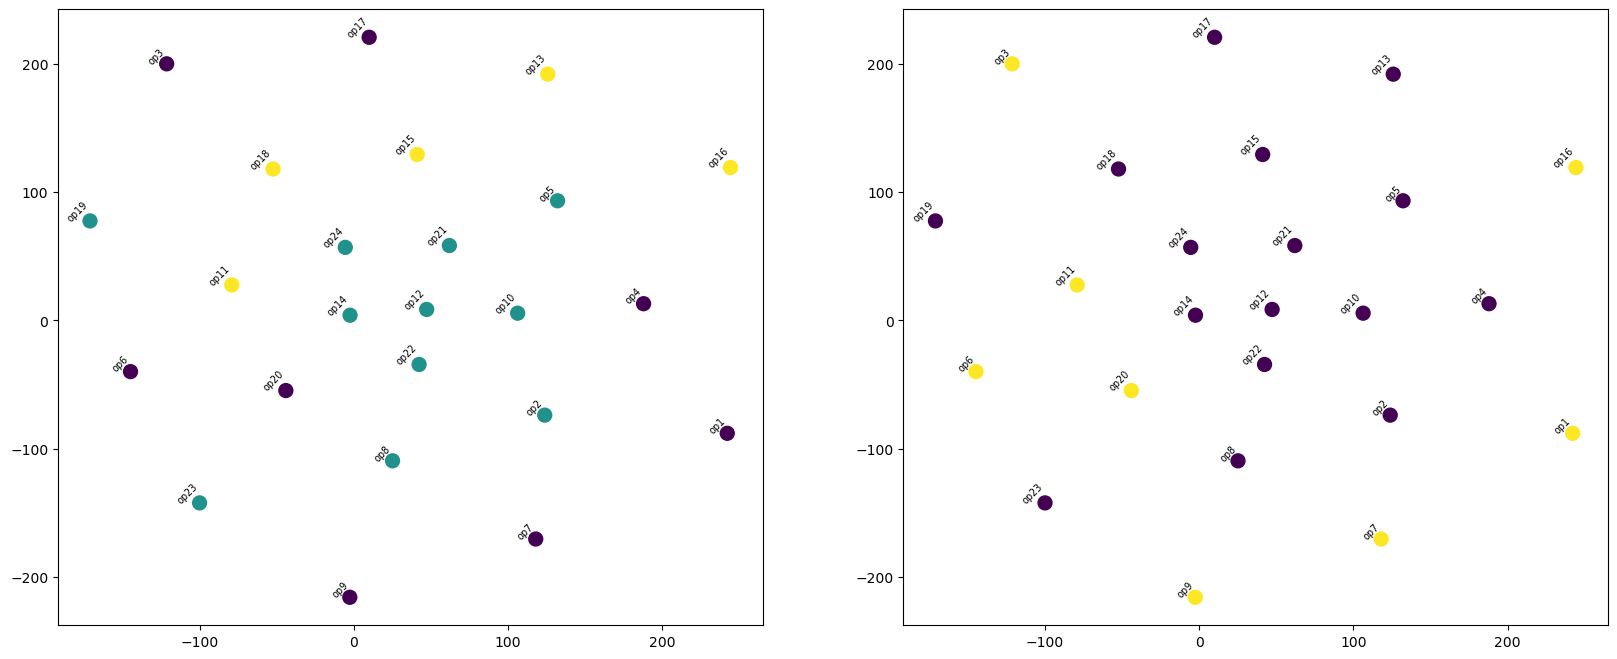

In [28]:
unweighted_hierachical_labels_k2 = fcluster(unweighted_linkage, t=2, criterion='maxclust') 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(unweightedEmbedding[:, 0], unweightedEmbedding[:,1], c=unweighted_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (unweightedEmbedding[i, 0], unweightedEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(unweightedEmbedding[:, 0], unweightedEmbedding[:,1], c=unweighted_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (unweightedEmbedding[i, 0], unweightedEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


    
ax1.set_title(f"Kmeans (k=3) - unweighted frame vectors ")
ax2.set_title(f"Kmeans (k=2) - unweighted frame vectors ")


plt.show()

In [ ]:
#comparing to manual annotations
unweighted_hierachical_labels_k2 = fcluster(unweighted_linkage, t=2, criterion='maxclust') 

unweighted_labels= [unweighted_kmeans_k2, unweighted_hierachical_labels_k2]

for i, label in enumerate(unweighted_labels): 
    print(f'ARI: {adjusted_rand_score(machinery_labels, unweighted_labels[i])}')

In [ ]:
print(f'ARI: {adjusted_rand_score(unweighted_kmeans_k2, unweighted_hierachical_labels_k2)}')

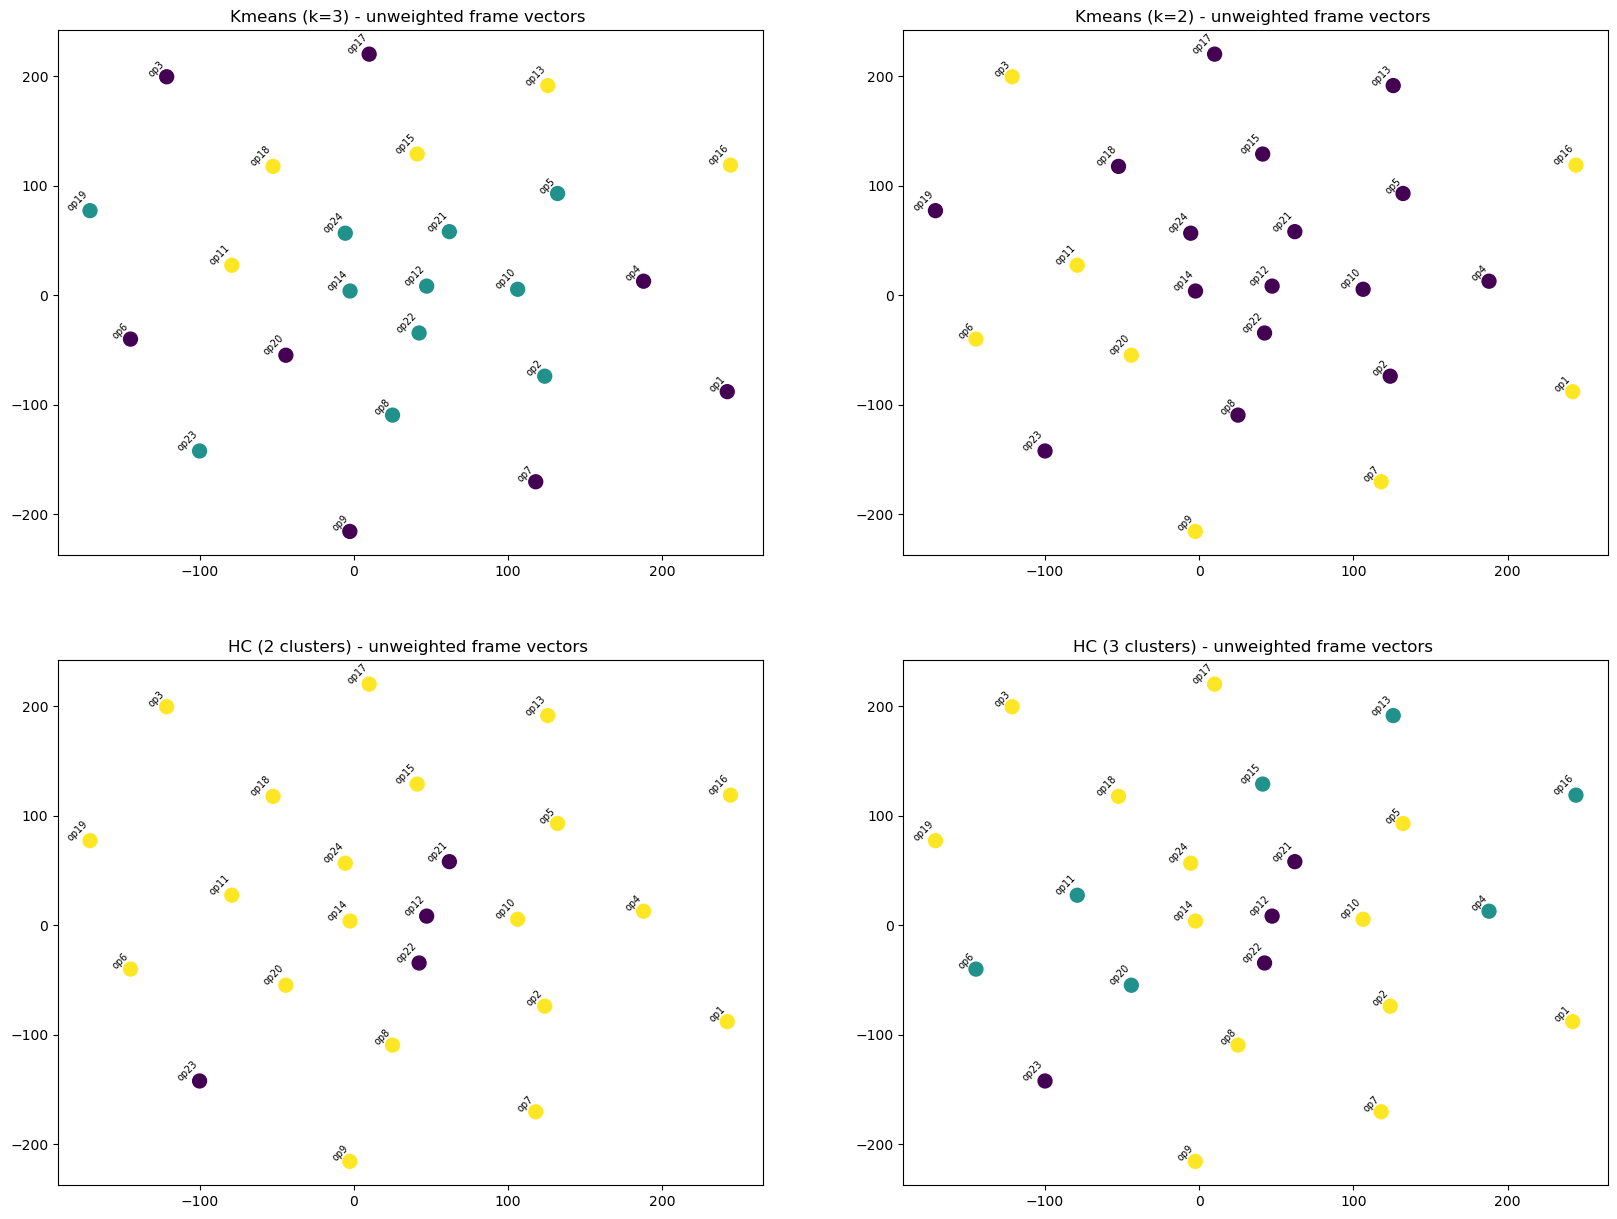

In [29]:
## plotting all resutls 
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
ax1,ax2, ax3,ax4 = axes.flatten()

ax1.scatter(unweightedEmbedding[:, 0], unweightedEmbedding[:,1], c=unweighted_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (unweightedEmbedding[i, 0], unweightedEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(unweightedEmbedding[:, 0], unweightedEmbedding[:,1], c=unweighted_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (unweightedEmbedding[i, 0], unweightedEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax3.scatter(unweightedEmbedding[:, 0], unweightedEmbedding[:,1], c=unweighted_hierachical_labels_k2, s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (unweightedEmbedding[i, 0], unweightedEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

ax4.scatter(unweightedEmbedding[:, 0], unweightedEmbedding[:,1], c=unweighted_hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax4.annotate(op, (unweightedEmbedding[i, 0], unweightedEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

    
ax1.set_title(f"Kmeans (k=3) - unweighted frame vectors ")
ax2.set_title(f"Kmeans (k=2) - unweighted frame vectors ")
ax3.set_title(f"HC (2 clusters) - unweighted frame vectors ")
ax4.set_title(f"HC (3 clusters) - unweighted frame vectors ")

plt.show()



### AHP weighing

In [ ]:
try:
    with open('ahpFrames.pkl', 'rb') as f:
        AhpWeightedFrameMatrix = pickle.load(f)
except:
    print("Error")



ahp_operations = []

for r in OP_RANGES:
    op = AhpWeightedFrameMatrix[r[0]:r[1]+1,]
    ahp_operations.append(op)

In [ ]:
ahpDists = n_dtw(ahp_operations)
ahpEmbedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(ahpDists)

ahp_condensedDist = squareform(ahpDists)
ahp_linkage = linkage(ahp_condensedDist, method='complete') 


plt.figure(figsize=(12, 8))
dendrogram(ahp_linkage, labels = opLabels)
plt.title("Operation Hiearchical Clustering - AHP frame vectors")
plt.show()

In [ ]:
ahp_hierachical_labels = fcluster(ahp_linkage, t=3, criterion='maxclust') 

plt.figure(figsize=(12, 8))
plt.scatter(ahpEmbedding[:, 0], ahpEmbedding[:, 1], 
            c=ahp_hierachical_labels, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (ahpEmbedding[i, 0], ahpEmbedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Hierarchical Clustering (3 clusters)')
plt.show()

In [ ]:
_, ahp_kmeans = kMeans_nDTW(ahp_operations, k=3)
_, ahp_kmeans_k2 = kMeans_nDTW(ahp_operations)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(ahpEmbedding[:, 0], ahpEmbedding[:,1], c=ahp_kmeans, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (ahpEmbedding[i, 0], ahpEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(ahpEmbedding[:, 0], ahpEmbedding[:,1], c=ahp_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (ahpEmbedding[i, 0], ahpEmbedding[i ,1]), fontsize=7, ha='right', rotation=45)

    
ax1.set_title(f"Kmeans (k=3) - ahp frame vectors ")
ax2.set_title(f"Kmeans (k=2) - ahp frame vectors ")

plt.show()

In [ ]:
##comparing against machinery
ahp_hierachical_labels_k2 = fcluster(ahp_linkage, t=2, criterion='maxclust') 


ahp_labels= [ahp_kmeans_k2, ahp_hierachical_labels, ahp_hierachical_labels_k2]

for i, label in enumerate(ahp_labels): 
    print(f'ARI: {adjusted_rand_score(machinery_labels, ahp_labels[i])}')

In [ ]:
##comparing results to original approach
equal_weight_labels = [0,1,0,1,0,0,0,1,0,0,0,1,1,1,0,0,0,0,1,0,1,1,1,1] 

print(f'ARI equal weighing vs ahp: {adjusted_rand_score(ahp_kmeans_k2, equal_weight_labels)}')

## Investigating interperson feature group

In [ ]:
poseMatrix = interpersonMatrix[:,:5]
jointMatrix = interpersonMatrix[:,5:]


pose_div = []
joint_dists = []

for r in OP_RANGES:
    op = poseMatrix[r[0]:r[1]+1,]
    pose_div.append(op)

for r in OP_RANGES:
    op = jointMatrix[r[0]:r[1]+1,]
    joint_dists.append(op)

### Pose diversity vs Joint distances

In [ ]:
##dendrograms
pose_div_dists = n_dtw(pose_div)
pose_div_embedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(pose_div_dists)

joint_dists_dists = n_dtw(joint_dists)
joint_dist_embedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(joint_dists_dists)



pose_condensedDist = squareform(pose_div_dists)
pose_linkage = linkage(pose_condensedDist, method='ward') 

joint_condensedDist = squareform(joint_dists_dists)
joint_linkage = linkage(joint_condensedDist, method='ward') 



fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(30, 8))

dendrogram(pose_linkage,  ax = ax1, labels = opLabels)
dendrogram(joint_linkage, ax = ax2, labels = opLabels)

ax1.set_title("Pose diversity")
ax2.set_title("Pairwise joint distances")

plt.show()

In [ ]:
#fcluster 
pose_div_hierarchical = fcluster(pose_linkage, t=2, criterion='maxclust') 
joint_dist_hierarchical = fcluster(joint_linkage, t=2, criterion='maxclust') 


In [ ]:
print(f'ARI pose div vs pw joint dist: {adjusted_rand_score(pose_div_hierarchical,joint_dist_hierarchical)}')

In [ ]:
#Kmeans
_, pose_div_kmeans = kMeans_nDTW(pose_div)
_, joint_dists_kmeans = kMeans_nDTW(joint_dists)


In [ ]:
#ARI 
interperson_labels = [pose_div_hierarchical,joint_dist_hierarchical, pose_div_kmeans, joint_dists_kmeans]

for i, label in enumerate(interperson_labels): 
    print(f'ARI: {adjusted_rand_score(machinery_labels, interperson_labels[i])}')

In [ ]:
print(f'ARI: {adjusted_rand_score(interperson_kmeans_k2, pose_div_kmeans)}') #comparing to full interperson group

#### ops > 10 frames 

In [ ]:
pose_div_over10 = []
joint_dists_over10 = []


for i, op in enumerate(pose_div):
    if len(op)>=10:
        pose_div_over10.append(pose_div[i])
        joint_dists_over10.append(joint_dists[i])

In [ ]:
_, pose_div_kmeans_over10 = kMeans_nDTW(pose_div_over10)
_, joint_dists_kmeans_over10 = kMeans_nDTW(joint_dists_over10)

In [ ]:
pose_div_dists_over10 = n_dtw(pose_div_over10)
joint_dists_dists_over10 = n_dtw(joint_dists_over10)

pose_condensedDist_over10 = squareform(pose_div_dists_over10)
pose_linkage_over10 = linkage(pose_condensedDist_over10, method='ward') 

joint_condensedDist_over10 = squareform(joint_dists_dists_over10)
joint_linkage_over10 = linkage(joint_condensedDist_over10, method='ward') 

#fcluster 
pose_div_hierarchical_over10 = fcluster(pose_linkage_over10, t=2, criterion='maxclust') 
joint_dist_hierarchical_over10 = fcluster(joint_linkage_over10, t=2, criterion='maxclust') 


In [ ]:
#ARI 
interperson_labels_over10 = [pose_div_hierarchical_over10 ,joint_dist_hierarchical_over10, pose_div_kmeans_over10, joint_dists_kmeans_over10]

for i, label in enumerate(interperson_labels_over10): 
    print(f'ARI: {adjusted_rand_score(machinery_labels_over10, interperson_labels_over10[i])}')

In [ ]:
print(f'ARI: {adjusted_rand_score(interperson_over10_kmeans, joint_dists_kmeans_over10)}') #comparing to full interperson group

### Experimenting with individual features

In [4]:
# Pose Diversity
pose_mean_matrix   = interpersonMatrix[:, 0]  # Mean diff
pose_std_matrix    = interpersonMatrix[:, 1]  # Std diff
pose_max_matrix    = interpersonMatrix[:, 2]  # Max diff
pose_maxdev_matrix = interpersonMatrix[:, 3]  # MaxDev (max - mean)
pose_min_matrix    = interpersonMatrix[:, 4]  # Min diff

# Person Distances
dist_mean_matrix   = interpersonMatrix[:, 5]  # Mean dist
dist_std_matrix    = interpersonMatrix[:, 6]  # Std dist
dist_min_matrix    = interpersonMatrix[:, 7]  # Min dist
dist_max_matrix    = interpersonMatrix[:, 8]  # Max dist

pose_mean   = []
pose_std    = []
pose_max    = []
pose_maxdev = []
pose_min    = []

dist_mean = []
dist_std  = []
dist_min  = []
dist_max  = []

for r in OP_RANGES:
    pose_mean.append(pose_mean_matrix[r[0]:r[1]+1,])
    pose_std.append(pose_std_matrix[r[0]:r[1]+1,])
    pose_max.append(pose_max_matrix[r[0]:r[1]+1,])
    pose_maxdev.append(pose_maxdev_matrix[r[0]:r[1]+1,])
    pose_min.append(pose_min_matrix[r[0]:r[1]+1,])

    dist_mean.append(dist_mean_matrix[r[0]:r[1]+1,])
    dist_std.append(dist_std_matrix[r[0]:r[1]+1,])
    dist_min.append(dist_min_matrix[r[0]:r[1]+1,])
    dist_max.append(dist_max_matrix[r[0]:r[1]+1,])

In [ ]:
##dendrograms
pose_mean_dists = n_dtw(pose_mean)
poseMean_condensedDist = squareform(pose_mean_dists)
pose_mean_linkage = linkage(poseMean_condensedDist, method='ward')

pose_std_dists = n_dtw(pose_std)
poseStd_condensedDist = squareform(pose_std_dists)
pose_std_linkage = linkage(poseStd_condensedDist, method='ward')

pose_max_dists = n_dtw(pose_max)
poseMax_condensedDist = squareform(pose_max_dists)
pose_max_linkage = linkage(poseMax_condensedDist, method='ward')

pose_maxdev_dists = n_dtw(pose_maxdev)
poseMaxdev_condensedDist = squareform(pose_maxdev_dists)
pose_maxdev_linkage = linkage(poseMaxdev_condensedDist, method='ward')

pose_min_dists = n_dtw(pose_min)
poseMin_condensedDist = squareform(pose_min_dists)
pose_min_linkage = linkage(poseMin_condensedDist, method='ward')

dist_mean_dists = n_dtw(dist_mean)
distMean_condensedDist = squareform(dist_mean_dists)
dist_mean_linkage = linkage(distMean_condensedDist, method='ward')

dist_std_dists = n_dtw(dist_std)
distStd_condensedDist = squareform(dist_std_dists)
dist_std_linkage = linkage(distStd_condensedDist, method='ward')

dist_min_dists = n_dtw(dist_min)
distMin_condensedDist = squareform(dist_min_dists)
dist_min_linkage = linkage(distMin_condensedDist, method='ward')

dist_max_dists = n_dtw(dist_max)
distMax_condensedDist = squareform(dist_max_dists)
dist_max_linkage = linkage(distMax_condensedDist, method='ward')

In [ ]:
pose_mean_labels   = fcluster(pose_mean_linkage, t=2, criterion='maxclust')
pose_std_labels    = fcluster(pose_std_linkage, t=2, criterion='maxclust')
pose_max_labels    = fcluster(pose_max_linkage, t=2, criterion='maxclust')
pose_maxdev_labels = fcluster(pose_maxdev_linkage, t=2, criterion='maxclust')
pose_min_labels    = fcluster(pose_min_linkage, t=2, criterion='maxclust')

dist_mean_labels = fcluster(dist_mean_linkage, t=2, criterion='maxclust')
dist_std_labels  = fcluster(dist_std_linkage, t=2, criterion='maxclust')
dist_min_labels  = fcluster(dist_min_linkage, t=2, criterion='maxclust')
dist_max_labels  = fcluster(dist_max_linkage, t=2, criterion='maxclust')

In [ ]:
##univariate kmeans 
from DBA import*

def assign_centroids_uni(X, centroids, cost_mat, delta_mat):
    labels = [] 
    for x in X:
        dists = [] #distance to each centroid
        for centroid in centroids:
            dists.append(squared_DTW(x, centroid, cost_mat, delta_mat))
        
        labels.append(np.argmin(dists))

    labels = np.array(labels)
    return labels


def update_centroids_uni(X, k, labels):
    new_centroids = []
    for i in range(k):
        series_in_cluster = []
        for x, l in zip(X, labels):
            if l == i:
                series_in_cluster.append(x)
        
        new_centroids.append(performDBA(series_in_cluster))

    return new_centroids

def compute_inertia_uni(X, N, labels, centroids, cost_mat, delta_mat):
    inertia = 0
    for i in range(N):
        inertia += squared_DTW(X[i], centroids[labels[i]], cost_mat, delta_mat)

    return inertia


def kMeans_nDTW_uni(X, k = 2, n_runs = 10, max_iter=100, random_state = None):
    '''
    X: operations
    k: # clusters
    n_runs: number of times we run algorithm before choosing best result
    max_iter: number of mean in kmeans algorithm
    random_state: param used to init random number generator


    return:
        - clustering labels
        - inertia
    '''

    rng = np.random.RandomState(random_state)
    N = len(X)
    bestInertia = np.inf
    bestLabels = None 

    #allocate matrices for NDTW computations
    max_length = max(x.shape[0] for x in X)
    cost_mat = np.zeros((max_length, max_length))
    delta_mat = np.zeros((max_length, max_length))
    path_mat = np.zeros((max_length, max_length), dtype=np.int8)



    for run in range(n_runs):

        #init centroids 
        centroid_indices = rng.choice(N, k, replace=False)
        centroids = [X[i] for i in centroid_indices]
        labels = np.zeros(N)

        for iteration in range(max_iter):
            prev_labels = labels.copy() 

            # assign each operation to nearest centroid (lowest nDTW dist)
            labels = assign_centroids_uni(X, centroids, cost_mat, delta_mat)

            #update centroid
            centroids = update_centroids_uni(X,k,labels)

            # check convergence
            if np.allclose(labels, prev_labels):
                break


        #compute inertia
        inertia = compute_inertia_uni(X, N, labels, centroids, cost_mat, delta_mat)


        #updating best inertia 
        if inertia < bestInertia:
            bestInertia = inertia
            bestLabel = labels
    
    return bestInertia, bestLabel

In [ ]:
_, pose_mean_kmeans   = kMeans_nDTW_uni(pose_mean)

In [ ]:
_, pose_std_kmeans    = kMeans_nDTW_uni(pose_std)

In [ ]:
_, pose_max_kmeans    = kMeans_nDTW_uni(pose_max)


In [ ]:
_, pose_maxdev_kmeans = kMeans_nDTW_uni(pose_maxdev)


In [ ]:
_, pose_min_kmeans    = kMeans_nDTW_uni(pose_min)

In [ ]:
_, dist_mean_kmeans = kMeans_nDTW_uni(dist_mean)

In [ ]:
_, dist_std_kmeans  = kMeans_nDTW_uni(dist_std)

In [ ]:
_, dist_min_kmeans  = kMeans_nDTW_uni(dist_min)

In [ ]:
_, dist_max_kmeans  = kMeans_nDTW_uni(dist_max)

In [ ]:
pose_div_labels = [pose_mean_kmeans, pose_std_kmeans, pose_max_kmeans, pose_maxdev_kmeans, pose_min_kmeans]
pose_div_labels_HC = [pose_mean_labels, pose_std_labels, pose_max_labels,pose_maxdev_labels, pose_min_labels]

for i, label in enumerate(pose_div_labels): 
    print(f'ARI: {adjusted_rand_score(machinery_labels, pose_div_labels[i])}')

print("\n")

for i, label in enumerate(pose_div_labels): 
    print(f'ARI: {adjusted_rand_score(machinery_labels, pose_div_labels_HC[i])}')

In [ ]:
dist_labels = [dist_mean_kmeans, dist_std_kmeans,  dist_min_kmeans, dist_max_kmeans]
dist_labels_HC = [dist_mean_labels, dist_std_labels, dist_min_labels, dist_max_labels]

for i, label in enumerate(dist_labels): 
    print(f'ARI: {adjusted_rand_score(machinery_labels, dist_labels[i])}')

print("\n")

for i, label in enumerate(dist_labels_HC): 
    print(f'ARI: {adjusted_rand_score(machinery_labels, dist_labels_HC[i])}')

In [ ]:
##checking features with exact same ARI
ari_014 = [pose_max_kmeans, pose_std_labels, dist_std_kmeans, dist_mean_labels, dist_min_labels ]
ari_029 = [dist_mean_kmeans, dist_min_kmeans, pose_std_kmeans]

for i in range(len(ari_014)):
    for j in range(i+1, len(ari_014)):
        print(f'ARI: {adjusted_rand_score(ari_014[i], ari_014[j])}')
    print("\n")

for i in range(len(ari_029)):
    for j in range(i+1, len(ari_029)):
        print(f'ARI: {adjusted_rand_score(ari_029[i], ari_029[j])}')


### Ops over 10 frames 

In [ ]:
pose_std_over10 = []
pose_max_over10 = []
dist_mean_over10 = []
dist_min_over10 = []
dist_std_over10 = []

for i, op in enumerate(pose_std):
    if len(op)>=10:
        pose_std_over10.append(pose_std[i])
        pose_max_over10.append(pose_max[i])
        dist_mean_over10.append(dist_mean[i])
        dist_min_over10.append(dist_min[i])
        dist_std_over10.append(dist_std[i])

In [ ]:
_, pose_std_kmeans_over10   = kMeans_nDTW_uni(pose_std_over10)


In [ ]:
_, pose_max_kmeans_over10   = kMeans_nDTW_uni(pose_max_over10)

In [ ]:
_, dist_mean_kmeans_over10  = kMeans_nDTW_uni(dist_mean_over10)

In [ ]:
_, dist_min_kmeans_over10  = kMeans_nDTW_uni(dist_min_over10)

In [ ]:
_, dist_std_kmeans_over10  = kMeans_nDTW_uni(dist_std_over10)

In [ ]:
pose_std_dists_over10 = n_dtw(pose_std_over10)
poseStd_condensedDist_over10 = squareform(pose_std_dists_over10)
pose_std_linkage_over10 = linkage(poseStd_condensedDist_over10, method='ward')

pose_max_dists_over10 = n_dtw(pose_max_over10)
poseMax_condensedDist_over10 = squareform(pose_max_dists_over10)
pose_max_linkage_over10 = linkage(poseMax_condensedDist_over10, method='ward')

dist_mean_dists_over10 = n_dtw(dist_mean_over10)
distMean_condensedDist_over10 = squareform(dist_mean_dists_over10)
dist_mean_linkage_over10 = linkage(distMean_condensedDist_over10, method='ward')

dist_std_dists_over10 = n_dtw(dist_std_over10)
distStd_condensedDist_over10 = squareform(dist_std_dists_over10)
dist_std_linkage_over10 = linkage(distStd_condensedDist_over10, method='ward')

dist_min_dists_over10 = n_dtw(dist_min_over10)
distMin_condensedDist_over10 = squareform(dist_min_dists_over10)
dist_min_linkage_over10 = linkage(distMin_condensedDist_over10, method='ward')


In [ ]:
pose_std_labels_over10  = fcluster(pose_std_linkage_over10, t=2, criterion='maxclust')
pose_max_labels_over10 = fcluster(pose_max_linkage_over10, t=2, criterion='maxclust')
dist_mean_labels_over10 = fcluster(dist_mean_linkage_over10, t=2, criterion='maxclust')
dist_std_labels_over10 = fcluster(dist_std_linkage_over10, t=2, criterion='maxclust')
dist_min_labels_over10  = fcluster(dist_min_linkage_over10, t=2, criterion='maxclust')


In [ ]:
interFeats_over10 = [pose_std_kmeans_over10, pose_max_kmeans_over10, dist_mean_kmeans_over10, dist_std_kmeans_over10] #dist_min_kmeans_over10
interFeats_over10_HC = [pose_std_labels_over10, dist_mean_labels_over10, dist_min_labels_over10, dist_std_labels_over10, pose_max_labels_over10]
for i, label in enumerate(interFeats_over10): 
    print(f'ARI: {adjusted_rand_score(machinery_labels_over10, interFeats_over10[i])}')

print("\n")

for i, label in enumerate(interFeats_over10_HC): 
    print(f'ARI: {adjusted_rand_score(machinery_labels_over10, interFeats_over10_HC[i])}')


##### Checking correlation between top interperson performers

In [ ]:
dist_corr = {
    'dist_mean': dist_mean_matrix,
    'dist_min': dist_min_matrix
}
dist_df = pd.DataFrame(dist_corr)

#Correlation for linear assumption
correlation = dist_df['dist_mean'].corr(dist_df['dist_min'])
print(f"Pearson Correlation: {correlation}")

#Correlations for non-linear data
spearman_corr =  dist_df['dist_mean'].corr(dist_df['dist_min'], method='spearman')
kendall_corr =  dist_df['dist_mean'].corr(dist_df['dist_min'], method='kendall')
print(f"Spearman Correlation: {spearman_corr}")
print(f"Kendall Correlation: {kendall_corr}")


Pearson Correlation: 0.9998145891194505
Spearman Correlation: 0.9993658596356716
Kendall Correlation: 0.9823906593932433


In [8]:
pose_corr = {
    'dist_mean': dist_mean_matrix,
    'pose_std': pose_std_matrix
}
pose_df = pd.DataFrame(pose_corr)

#Correlation for linear assumption
correlation = pose_df['dist_mean'].corr(pose_df['pose_std'])
print(f"Pearson Correlation: {correlation}")

#Correlations for non-linear data
spearman_corr =  pose_df['dist_mean'].corr(pose_df['pose_std'], method='spearman')
kendall_corr =  pose_df['dist_mean'].corr(pose_df['pose_std'], method='kendall')
print(f"Spearman Correlation: {spearman_corr}")
print(f"Kendall Correlation: {kendall_corr}")


Pearson Correlation: 0.9982105506458052
Spearman Correlation: 0.9938797439392193
Kendall Correlation: 0.9340032538998947
